In [1]:
# Cell 1 — Setup & Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load emails data
df = pd.read_csv('../../data/raw/emails.csv', low_memory=False)

# Basic info
print(f"Dataset Shape: {df.shape}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nFirst 5 Rows:")
df.head()

Dataset Shape: (123389, 27)

Data Types:
Co_Ref                                  object
Time_to_Renewal                         object
crm_accreditation_completed             object
crm_timely_completion                   object
crm_progress_towards_accreditation      object
crm_delays_in_accreditation             object
crm_contractor_suggested_leave          object
crm_contractor_engagement               object
crm_contractor_sentiment                object
crm_contractor_sentiment_score          object
crm_dts_or_ssip_mentioned               object
crm_customer_payment_intention          object
crm_competitors_mentioned               object
crm_membership_level                    object
crm_platform_issues_raised              object
crm_agent_chased_contractor             object
crm_agent_chase_count                   object
crm_accreditation_issues                object
crm_membership_overdue                  object
crm_auto_renewal_status                 object
crm_dissatisified_w

,Co_Ref,Time_to_Renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,...,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
1,EJ1532,14_out,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,...,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
2,AA4063,prior_year,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,50,...,Not Discussed,No,0,No,No,Yes,Yes,Yes,Not Discussed,2025
3,JY9888,prior_year,No,No,Not Discussed,Yes,No,Yes,Satisfied,80,...,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,...,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026


In [2]:
# Cell 2 — Column Inventory
# Every column, dtype, null count in one table.
# This file has 27 columns — many are Yes/No flags.

column_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2)
})

# Classify columns by content type
yes_no_flags = []
numeric_cols = []
free_text_cols = []
id_cols = []

for col in df.columns:
    unique_vals = set(df[col].dropna().unique())
    # Check if it's an ID column
    if col in ['Co_Ref']:
        id_cols.append(col)
    # Check if it's a categorical / time-window column
    elif col in ['Time_to_Renewal']:
        id_cols.append(col)  # treat as categorical ID
    # Check if it's numeric
    elif df[col].dtype in ['int64', 'float64']:
        numeric_cols.append(col)
    # Check if it's a Yes/No flag
    elif unique_vals.issubset({'Yes', 'No', 'Not Discussed'}) or \
         (len(unique_vals) <= 5 and 'Yes' in unique_vals and 'No' in unique_vals):
        yes_no_flags.append(col)
    else:
        free_text_cols.append(col)

print("COLUMN INVENTORY:")
print(column_info.to_string(index=False))
print(f"\n--- Column Classification ---")
print(f"ID / Categorical columns: {id_cols}")
print(f"Yes/No Flag columns ({len(yes_no_flags)}): {yes_no_flags}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Free-text / Mixed columns ({len(free_text_cols)}): {free_text_cols}")

Dataset Shape: (123389, 27)

Data Types:
Co_Ref                                  object
Time_to_Renewal                         object
crm_accreditation_completed             object
crm_timely_completion                   object
crm_progress_towards_accreditation      object
crm_delays_in_accreditation             object
crm_contractor_suggested_leave          object
crm_contractor_engagement               object
crm_contractor_sentiment                object
crm_contractor_sentiment_score          object
crm_dts_or_ssip_mentioned               object
crm_customer_payment_intention          object
crm_competitors_mentioned               object
crm_membership_level                    object
crm_platform_issues_raised              object
crm_agent_chased_contractor             object
crm_agent_chase_count                   object
crm_accreditation_issues                object
crm_membership_overdue                  object
crm_auto_renewal_status                 object
crm_dissatisified_w

,Co_Ref,Time_to_Renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year
0,KG5766,pre_renewal,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,50,...,Not Discussed,Yes,0,No,No,Yes,Yes,No,Yes,2025
1,EJ1532,14_out,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Not Discussed,...,Not Discussed,Not Discussed,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
2,AA4063,prior_year,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,50,...,Not Discussed,No,0,No,No,Yes,Yes,Yes,Not Discussed,2025
3,JY9888,prior_year,No,No,Not Discussed,Yes,No,Yes,Satisfied,80,...,Not Discussed,Yes,0,Not Discussed,No,Yes,Yes,No,Not Discussed,2025
4,WO6689,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,80,...,No,No,0,No,No,Yes,Yes,No,Not Discussed,2026


Row count per year:
year
2024        2
2025    81625
2026    41762
Name: count, dtype: int64



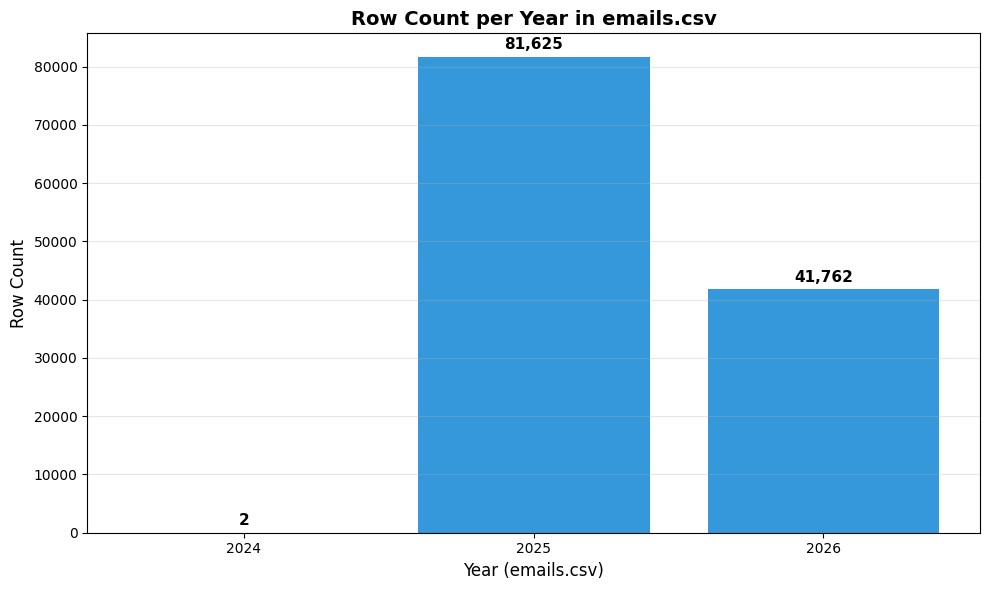


⚠️  CRITICAL NOTE: YEAR OFFSET
emails.year = billings.Renewal_Year + 1

Year 2024 in emails → Renewal_Year 2023 in billings (2 rows – negligible)
Year 2025 in emails → Renewal_Year 2024 in billings (81,625 rows – bulk of data)
Year 2026 in emails → Renewal_Year 2025 in billings (41,762 rows)
Year 2023 in emails → 0 rows


In [3]:
# Cell 3 — The Year Column (critical — understand this first)
# ============================================================
#
# This cell exists purely to make the year confusion IMPOSSIBLE to forget.
#
# The emails.csv `year` column does NOT correspond to Renewal_Year in billings.
# Instead:  emails.year  =  Renewal_Year + 1
#
# So year=2025 in emails → Renewal_Year=2024 in billings
#    year=2026 in emails → Renewal_Year=2025 in billings
#    year=2024 in emails → Renewal_Year=2023 in billings (only 2 rows)
#
# There are 0 rows with year=2023 in emails.
#

year_counts = df['year'].value_counts().sort_index()
print("Row count per year:")
print(year_counts)
print()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#95a5a6' if c < 100 else '#3498db' for c in year_counts.values]
bars = ax.bar(year_counts.index.astype(str), year_counts.values, color=colors)

for i, (yr, cnt) in enumerate(zip(year_counts.index, year_counts.values)):
    ax.text(i, cnt + max(year_counts.values)*0.01, f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Year (emails.csv)', fontsize=12)
ax.set_ylabel('Row Count', fontsize=12)
ax.set_title('Row Count per Year in emails.csv', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("⚠️  CRITICAL NOTE: YEAR OFFSET")
print("="*60)
print("emails.year = billings.Renewal_Year + 1")
print("")
print("Year 2024 in emails → Renewal_Year 2023 in billings (2 rows – negligible)")
print("Year 2025 in emails → Renewal_Year 2024 in billings (81,625 rows – bulk of data)")
print("Year 2026 in emails → Renewal_Year 2025 in billings (41,762 rows)")
print("Year 2023 in emails → 0 rows")
print("="*60)

Time_to_Renewal value counts:
  prior_year      → 40,022 rows (32.4%)
  14_out          → 32,493 rows (26.3%)
  45_out          → 28,008 rows (22.7%)
  pre_renewal     → 22,866 rows (18.5%)


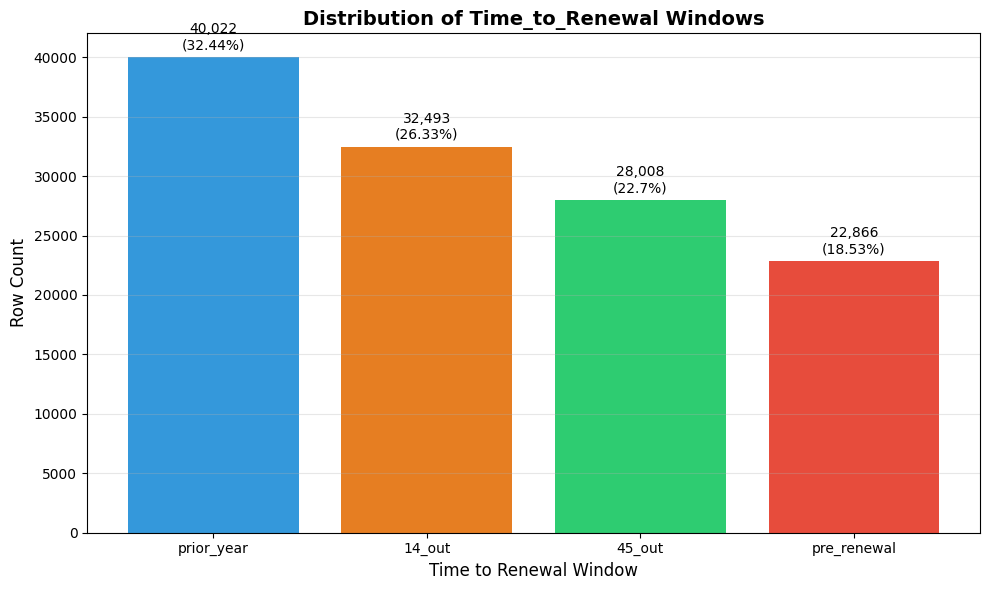


=== ANSWERS ===
All 4 windows present: True
Any nulls? 0
Richest window: prior_year with 40,022 rows (32.44%)
Coverage is uneven — prior_year dominates, pre_renewal has fewest rows.


In [4]:
# Cell 4 — Time to Renewal Windows
# Which window is richest in data?
# This maps directly to which model uses which window.

ttr_counts = df['Time_to_Renewal'].value_counts()
ttr_pct = (ttr_counts / len(df) * 100).round(2)

print("Time_to_Renewal value counts:")
for window, cnt in ttr_counts.items():
    print(f"  {window:15s} → {cnt:>6,} rows ({ttr_pct[window]:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
palette = {'prior_year': '#3498db', '45_out': '#2ecc71', '14_out': '#e67e22', 'pre_renewal': '#e74c3c'}
bar_colors = [palette.get(w, '#95a5a6') for w in ttr_counts.index]
bars = ax.bar(ttr_counts.index, ttr_counts.values, color=bar_colors)

for i, (cnt, pct) in enumerate(zip(ttr_counts.values, ttr_pct.values)):
    ax.text(i, cnt + max(ttr_counts.values)*0.01, f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Time to Renewal Window', fontsize=12)
ax.set_ylabel('Row Count', fontsize=12)
ax.set_title('Distribution of Time_to_Renewal Windows', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== ANSWERS ===")
print(f"All 4 windows present: {set(ttr_counts.index) == {'prior_year','45_out','14_out','pre_renewal'}}")
print(f"Any nulls? {df['Time_to_Renewal'].isnull().sum()}")
richest = ttr_counts.idxmax()
print(f"Richest window: {richest} with {ttr_counts[richest]:,} rows ({ttr_pct[richest]}%)")
print(f"Coverage is uneven — prior_year dominates, pre_renewal has fewest rows.")

Unique customers in EMAILS:   37,964
Unique customers in BILLINGS: 47,826
Overlap (in both):            37,964
% of billing customers with email records: 79.4%


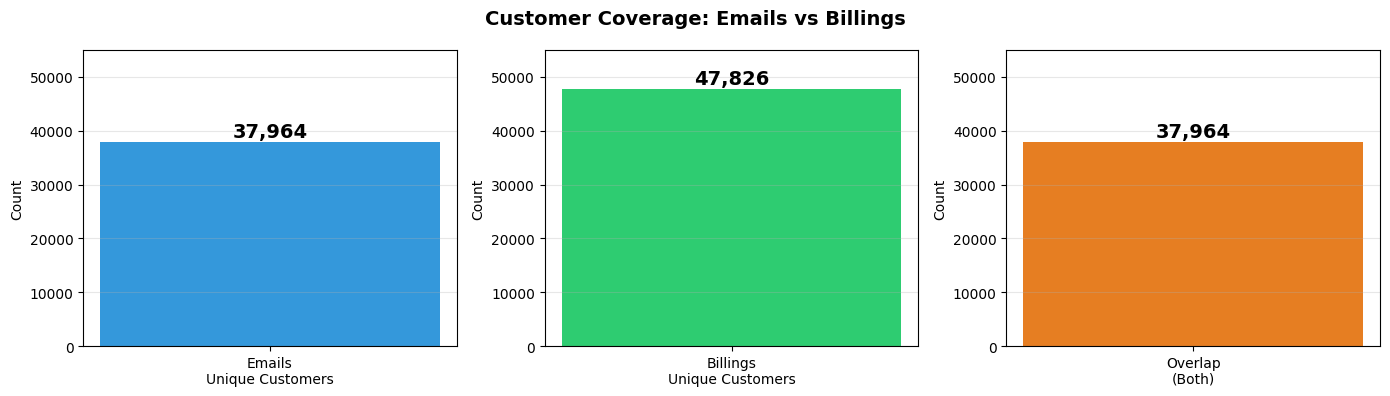


--- Unique Customers per Time_to_Renewal Window ---
  prior_year      → 36,437 unique customers
  45_out          → 25,200 unique customers
  14_out          → 29,278 unique customers
  pre_renewal     → 21,362 unique customers


In [5]:
# Cell 5 — Customer Coverage
# How many unique Co_Ref values appear in emails vs billings? How many overlap?

df_billings = pd.read_csv('../../data/raw/billings.csv', low_memory=False)

email_customers = set(df['Co_Ref'].unique())
billing_customers = set(df_billings['Co_Ref'].unique())
overlap = email_customers & billing_customers

n_email = len(email_customers)
n_billing = len(billing_customers)
n_overlap = len(overlap)
pct_coverage = n_overlap / n_billing * 100

print("=" * 50)
print(f"Unique customers in EMAILS:   {n_email:>6,}")
print(f"Unique customers in BILLINGS: {n_billing:>6,}")
print(f"Overlap (in both):            {n_overlap:>6,}")
print(f"% of billing customers with email records: {pct_coverage:.1f}%")
print("=" * 50)

# Visualisation: simple stat boxes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
stats = [
    ('Emails\nUnique Customers', n_email, '#3498db'),
    ('Billings\nUnique Customers', n_billing, '#2ecc71'),
    ('Overlap\n(Both)', n_overlap, '#e67e22'),
]
for ax, (label, val, color) in zip(axes, stats):
    ax.bar([label], [val], color=color, width=0.5)
    ax.text(0, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(n_email, n_billing) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel('Count')
fig.suptitle('Customer Coverage: Emails vs Billings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Break down by Time_to_Renewal window
print("\n--- Unique Customers per Time_to_Renewal Window ---")
for window in ['prior_year', '45_out', '14_out', 'pre_renewal']:
    n = df[df['Time_to_Renewal'] == window]['Co_Ref'].nunique()
    print(f"  {window:15s} → {n:>6,} unique customers")

Emails per customer — summary statistics:
count    37964.00
mean         3.25
std          1.26
min          1.00
25%          2.00
50%          3.00
75%          4.00
max          8.00
dtype: float64

Median: 3.0


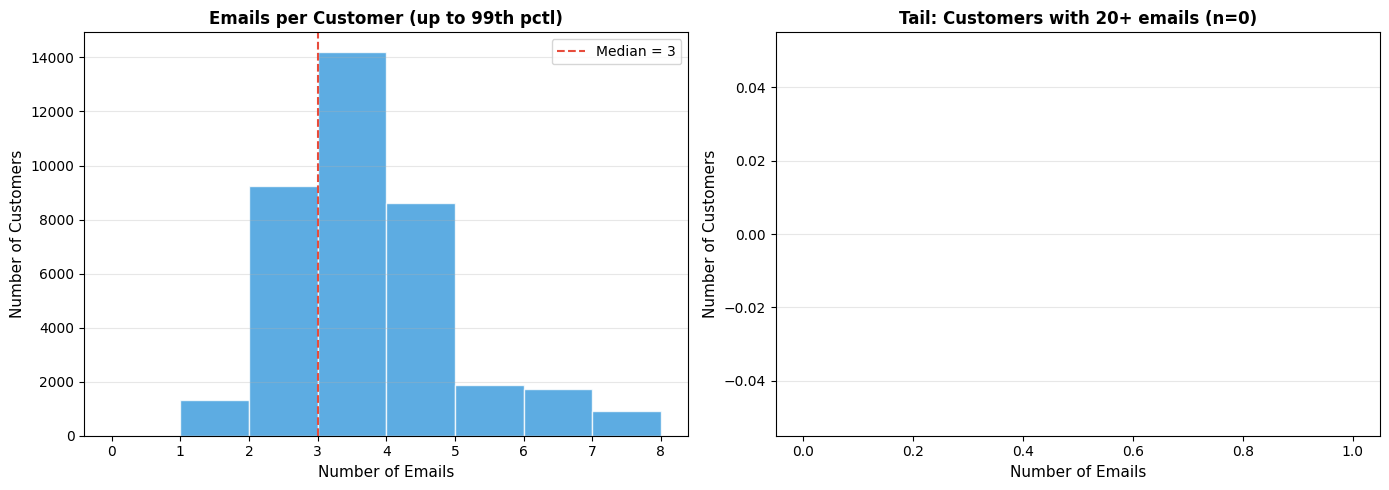


Customers with 1 email:  1,339
Customers with 20+ emails: 0
Max emails for a single customer: 8


In [6]:
# Cell 6 — Emails per Customer Distribution
# How many emails does a typical customer have?

emails_per_customer = df.groupby('Co_Ref').size()

print("Emails per customer — summary statistics:")
print(emails_per_customer.describe().round(2))
print(f"\nMedian: {emails_per_customer.median()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram (full)
ax = axes[0]
ax.hist(emails_per_customer, bins=range(0, int(emails_per_customer.quantile(0.99)) + 2), color='#3498db', edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of Emails', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title('Emails per Customer (up to 99th pctl)', fontsize=12, fontweight='bold')
ax.axvline(emails_per_customer.median(), color='#e74c3c', linestyle='--', label=f'Median = {emails_per_customer.median():.0f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: Tail — customers with 20+ emails
ax = axes[1]
tail = emails_per_customer[emails_per_customer >= 20]
ax.hist(tail, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of Emails', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title(f'Tail: Customers with 20+ emails (n={len(tail):,})', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCustomers with 1 email:  {(emails_per_customer == 1).sum():,}")
print(f"Customers with 20+ emails: {(emails_per_customer >= 20).sum():,}")
print(f"Max emails for a single customer: {emails_per_customer.max()}")

Sentiment value counts (cleaned):
sentiment_clean
Neutral          53576
Not Discussed    31167
Satisfied        11405
Dissatisfied      6177
Name: count, dtype: int64
Rows with unrecognised sentiment values: 29


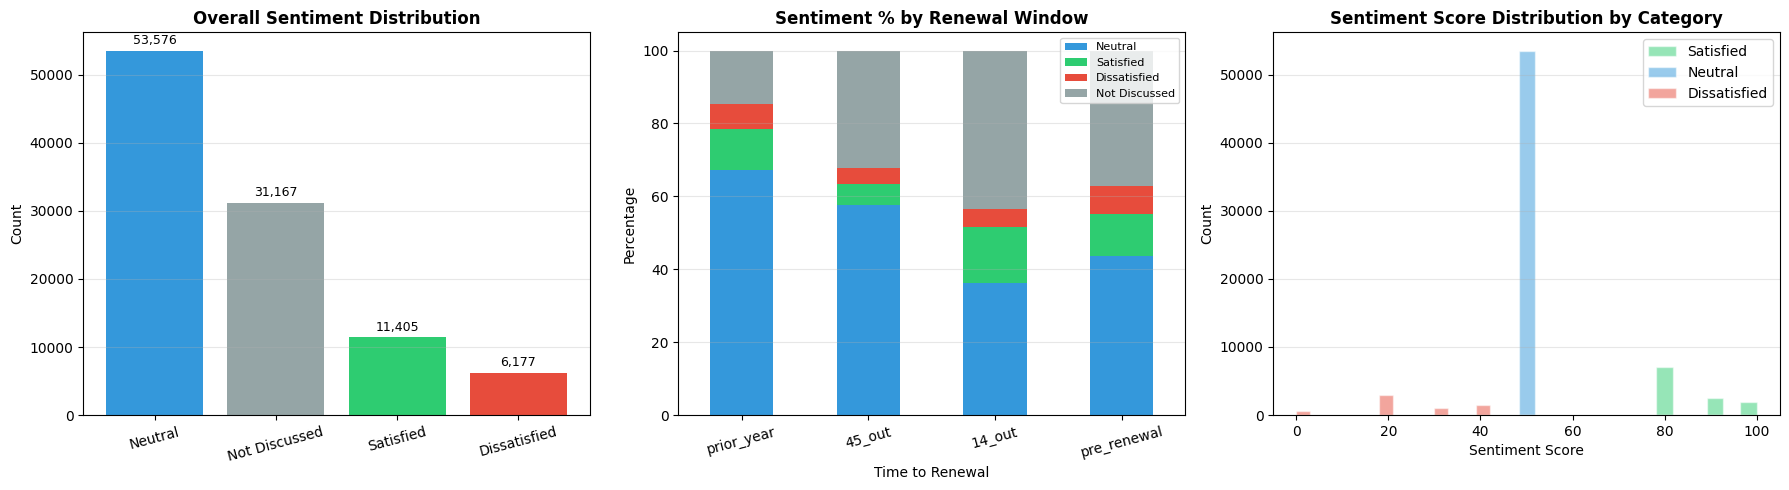


=== KEY QUESTION: Does sentiment get more negative as renewal approaches? ===
sentiment_clean  Neutral  Satisfied  Dissatisfied  Not Discussed
Time_to_Renewal                                                 
prior_year          67.3       11.1           7.1           14.6
45_out              57.6        5.9           4.3           32.2
14_out              36.1       15.4           5.1           43.4
pre_renewal         43.7       11.4           7.6           37.2

↑ Look at the 'Dissatisfied' column — does it increase from prior_year → pre_renewal?


In [7]:
# Cell 7 — Sentiment Analysis (your most powerful signal)
# =======================================================

# Clean the sentiment column — keep only the main categories
valid_sentiments = ['Neutral', 'Satisfied', 'Dissatisfied', 'Not Discussed']
df['sentiment_clean'] = df['crm_contractor_sentiment'].apply(
    lambda x: x if x in valid_sentiments else np.nan
)

# --- Visualisation 1: Bar chart of sentiment value counts ---
sent_counts = df['sentiment_clean'].value_counts()
print("Sentiment value counts (cleaned):")
print(sent_counts)
print(f"Rows with unrecognised sentiment values: {df['sentiment_clean'].isna().sum() - df['crm_contractor_sentiment'].isna().sum()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Overall sentiment
ax = axes[0]
colors_sent = {'Neutral': '#3498db', 'Satisfied': '#2ecc71', 'Dissatisfied': '#e74c3c', 'Not Discussed': '#95a5a6'}
bar_c = [colors_sent.get(s, '#bdc3c7') for s in sent_counts.index]
ax.bar(sent_counts.index, sent_counts.values, color=bar_c)
for i, (cnt) in enumerate(sent_counts.values):
    ax.text(i, cnt + max(sent_counts.values)*0.01, f'{cnt:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Overall Sentiment Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

# --- Visualisation 2: Stacked bar — sentiment split by Time_to_Renewal ---
ax = axes[1]
ct = pd.crosstab(df['Time_to_Renewal'], df['sentiment_clean'])
# Reorder columns
for c in valid_sentiments:
    if c not in ct.columns:
        ct[c] = 0
ct = ct[valid_sentiments]
# Reorder rows
order = ['prior_year', '45_out', '14_out', 'pre_renewal']
ct = ct.reindex(order)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, ax=ax, color=[colors_sent[s] for s in ct_pct.columns])
ax.set_title('Sentiment % by Renewal Window', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xlabel('Time to Renewal')
ax.legend(loc='upper right', fontsize=8)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

# --- Visualisation 3: Histogram of crm_contractor_sentiment_score ---
ax = axes[2]
# Parse score to numeric
df['sentiment_score_num'] = pd.to_numeric(df['crm_contractor_sentiment_score'], errors='coerce')
for sent_cat, color in [('Satisfied', '#2ecc71'), ('Neutral', '#3498db'), ('Dissatisfied', '#e74c3c')]:
    subset = df[df['sentiment_clean'] == sent_cat]['sentiment_score_num'].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.5, label=sent_cat, color=color, edgecolor='white')
ax.set_title('Sentiment Score Distribution by Category', fontsize=12, fontweight='bold')
ax.set_xlabel('Sentiment Score')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== KEY QUESTION: Does sentiment get more negative as renewal approaches? ===")
print(ct_pct.round(1).to_string())
print("\n↑ Look at the 'Dissatisfied' column — does it increase from prior_year → pre_renewal?")

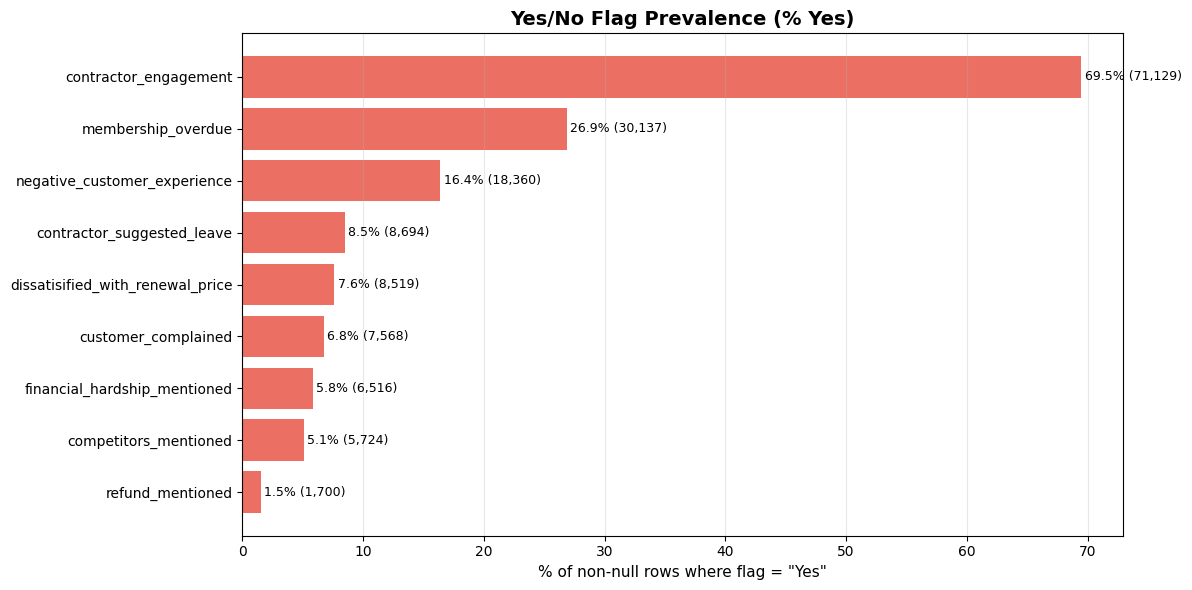


=== Flag Summary ===
                            Flag  Yes_Count  Non_Null  Yes_%
                refund_mentioned       1700    111914   1.52
           competitors_mentioned       5724    112234   5.10
    financial_hardship_mentioned       6516    111914   5.82
             customer_complained       7568    111914   6.76
dissatisified_with_renewal_price       8519    112234   7.59
      contractor_suggested_leave       8694    102354   8.49
    negative_customer_experience      18360    111914  16.41
              membership_overdue      30137    112234  26.85
           contractor_engagement      71129    102354  69.49

Rarest flags (< 5% Yes) are often the most powerful predictors — they are strong churn signals.


In [8]:
# Cell 8 — The Flag Columns
# Horizontal bar chart — % of rows where each flag = "Yes"

flag_columns = [
    'crm_contractor_suggested_leave',
    'crm_competitors_mentioned',
    'crm_dissatisified_with_renewal_price',
    'crm_customer_complained',
    'crm_contractor_engagement',
    'crm_membership_overdue',
    'crm_financial_hardship_mentioned',
    'crm_refund_mentioned',
    'crm_negative_customer_experience',
]

flag_stats = []
for col in flag_columns:
    non_null = df[col].notna().sum()
    yes_count = (df[col] == 'Yes').sum()
    pct = yes_count / max(non_null, 1) * 100
    flag_stats.append({'Flag': col.replace('crm_', ''), 'Yes_Count': yes_count, 'Non_Null': non_null, 'Yes_%': round(pct, 2)})

flag_df = pd.DataFrame(flag_stats).sort_values('Yes_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(flag_df['Flag'], flag_df['Yes_%'], color='#e74c3c', alpha=0.8)
for i, (pct, cnt) in enumerate(zip(flag_df['Yes_%'].values, flag_df['Yes_Count'].values)):
    ax.text(pct + 0.3, i, f'{pct:.1f}% ({cnt:,})', va='center', fontsize=9)
ax.set_xlabel('% of non-null rows where flag = "Yes"', fontsize=11)
ax.set_title('Yes/No Flag Prevalence (% Yes)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Flag Summary ===")
print(flag_df.to_string(index=False))
print("\nRarest flags (< 5% Yes) are often the most powerful predictors — they are strong churn signals.")

Chase count summary:
count    111696.00
mean          1.37
std           1.42
min           0.00
25%           0.00
50%           1.00
75%           2.00
max          24.00
Name: chase_count_num, dtype: float64

Rows with valid chase count: 111,696


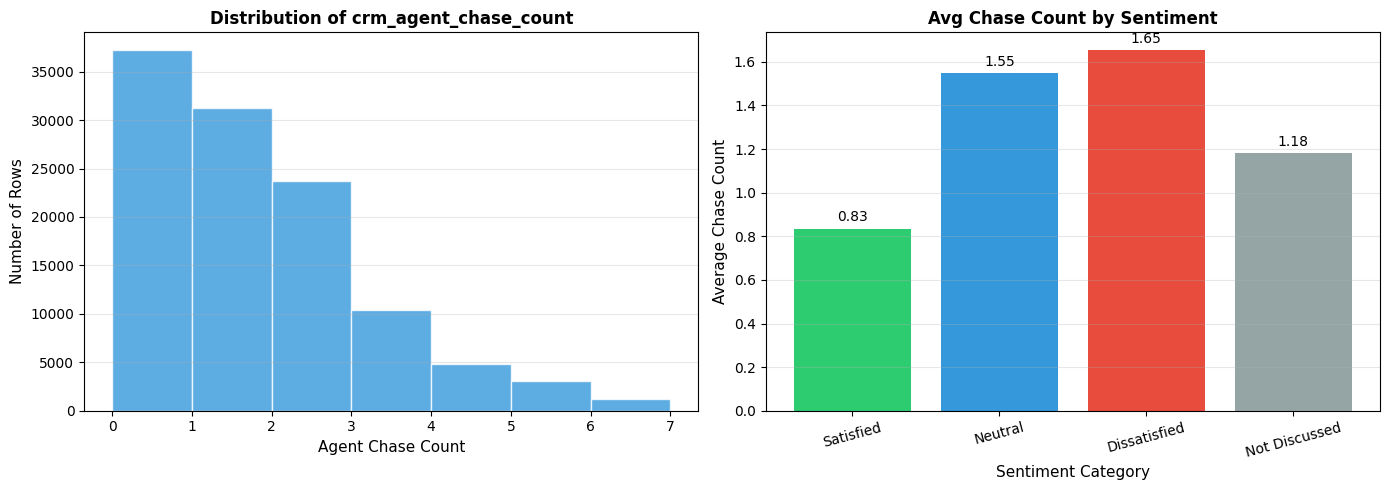


Customers chased > 3 times: 9,151 (8.2%)
Customers with 0 chases: 37,199 (33.3%)


In [9]:
# Cell 9 — Agent Chase Count
# crm_agent_chase_count is stored as object due to mixed types; convert.

df['chase_count_num'] = pd.to_numeric(df['crm_agent_chase_count'], errors='coerce')

print("Chase count summary:")
print(df['chase_count_num'].describe().round(2))
print(f"\nRows with valid chase count: {df['chase_count_num'].notna().sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of chase count
ax = axes[0]
valid_chase = df['chase_count_num'].dropna()
max_bin = int(min(valid_chase.quantile(0.99), 20)) + 1
ax.hist(valid_chase, bins=range(0, max_bin + 1), color='#3498db', edgecolor='white', alpha=0.8)
ax.set_xlabel('Agent Chase Count', fontsize=11)
ax.set_ylabel('Number of Rows', fontsize=11)
ax.set_title('Distribution of crm_agent_chase_count', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Bar chart — average chase count by sentiment category
ax = axes[1]
avg_chase = df.groupby('sentiment_clean')['chase_count_num'].mean().dropna()
avg_chase = avg_chase.reindex(['Satisfied', 'Neutral', 'Dissatisfied', 'Not Discussed'])
colors_sent2 = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
ax.bar(avg_chase.index, avg_chase.values, color=colors_sent2)
for i, val in enumerate(avg_chase.values):
    ax.text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Sentiment Category', fontsize=11)
ax.set_ylabel('Average Chase Count', fontsize=11)
ax.set_title('Avg Chase Count by Sentiment', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

chased_3_plus = (valid_chase > 3).sum()
print(f"\nCustomers chased > 3 times: {chased_3_plus:,} ({chased_3_plus/len(valid_chase)*100:.1f}%)")
print(f"Customers with 0 chases: {(valid_chase == 0).sum():,} ({(valid_chase == 0).sum()/len(valid_chase)*100:.1f}%)")

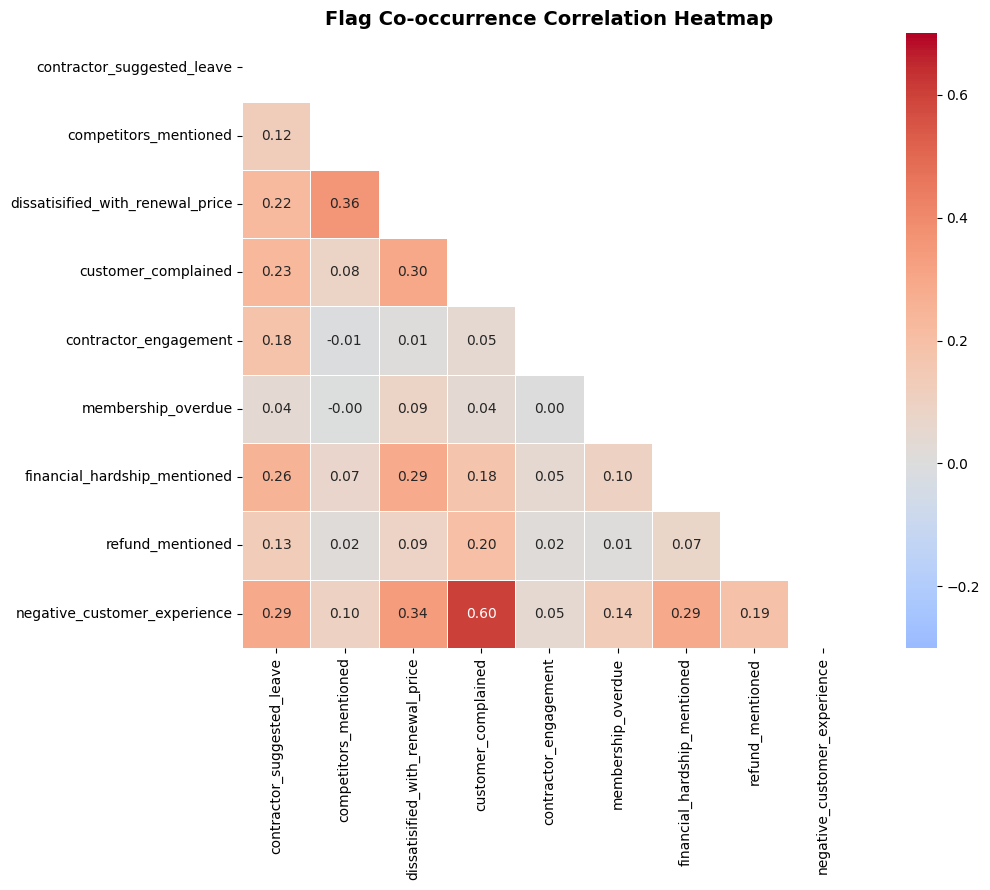


=== Specific Co-occurrence Checks ===
When suggested_leave=Yes, competitors_mentioned=Yes: 14.1%
When dissatisfied_with_price=Yes, sentiment=Dissatisfied: 27.6%

↑ High co-occurrence = multicollinearity risk. Consider dropping one of highly correlated pairs.


In [10]:
# Cell 10 — Flag Co-occurrence
# Heatmap: when one flag = Yes, how often does another also = Yes?
# This tells you which flags cluster together (multicollinearity risk).

# Create binary Yes/Not-Yes matrix for flag columns
flag_binary = pd.DataFrame()
for col in flag_columns:
    col_short = col.replace('crm_', '')
    flag_binary[col_short] = (df[col] == 'Yes').astype(int)

# Correlation matrix
corr = flag_binary.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, vmin=-0.3, vmax=0.7, square=True, linewidths=0.5)
ax.set_title('Flag Co-occurrence Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Specific co-occurrence checks
print("\n=== Specific Co-occurrence Checks ===")

# When suggested_leave = Yes, how often is competitors_mentioned = Yes?
suggested_leave = df[df['crm_contractor_suggested_leave'] == 'Yes']
if len(suggested_leave) > 0:
    comp_pct = (suggested_leave['crm_competitors_mentioned'] == 'Yes').sum() / len(suggested_leave) * 100
    print(f"When suggested_leave=Yes, competitors_mentioned=Yes: {comp_pct:.1f}%")

# When dissatisfied_with_renewal_price = Yes, how often is sentiment Dissatisfied?
price_dissat = df[df['crm_dissatisified_with_renewal_price'] == 'Yes']
if len(price_dissat) > 0:
    sent_pct = (price_dissat['sentiment_clean'] == 'Dissatisfied').sum() / len(price_dissat) * 100
    print(f"When dissatisfied_with_price=Yes, sentiment=Dissatisfied: {sent_pct:.1f}%")

print("\n↑ High co-occurrence = multicollinearity risk. Consider dropping one of highly correlated pairs.")

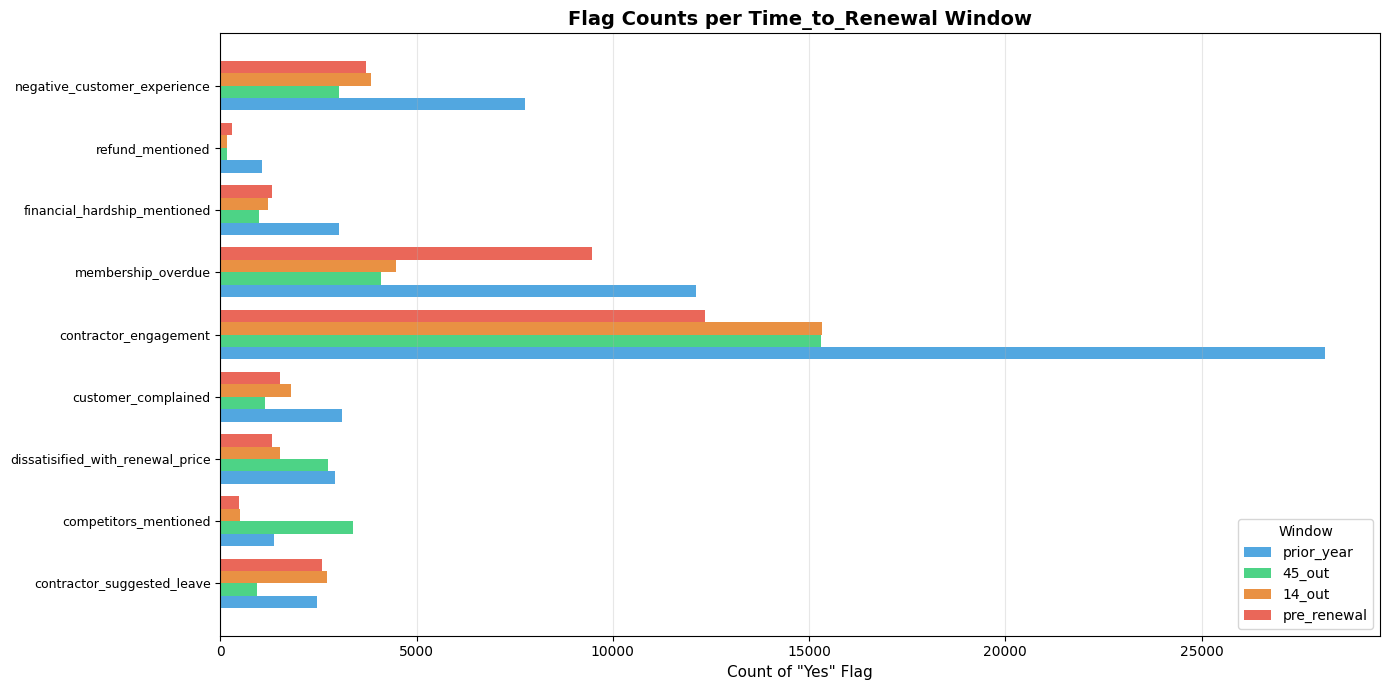


--- Non-null coverage per window (% of rows with non-null values) ---

prior_year (40,022 rows):
  contractor_suggested_leave               → 82.3% populated
  competitors_mentioned                    → 91.0% populated
  dissatisified_with_renewal_price         → 91.0% populated
  customer_complained                      → 90.9% populated
  contractor_engagement                    → 82.3% populated
  membership_overdue                       → 91.0% populated
  financial_hardship_mentioned             → 90.9% populated
  refund_mentioned                         → 90.9% populated
  negative_customer_experience             → 90.9% populated

45_out (28,008 rows):
  contractor_suggested_leave               → 80.6% populated
  competitors_mentioned                    → 90.0% populated
  dissatisified_with_renewal_price         → 90.0% populated
  customer_complained                      → 89.8% populated
  contractor_engagement                    → 80.6% populated
  membership_overdue     

In [11]:
# Cell 11 — Coverage per Window (readiness check)
# For each Time_to_Renewal window, how many customers have each flag?
# Are some columns only filled for certain windows?

windows = ['prior_year', '45_out', '14_out', 'pre_renewal']

# Build a table: rows = flags, columns = windows, values = count of Yes
coverage_data = {}
for window in windows:
    subset = df[df['Time_to_Renewal'] == window]
    counts = {}
    for col in flag_columns:
        col_short = col.replace('crm_', '')
        yes_count = (subset[col] == 'Yes').sum()
        counts[col_short] = yes_count
    coverage_data[window] = counts

coverage_df = pd.DataFrame(coverage_data)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(coverage_df))
width = 0.2

palette_w = {'prior_year': '#3498db', '45_out': '#2ecc71', '14_out': '#e67e22', 'pre_renewal': '#e74c3c'}
for i, window in enumerate(windows):
    ax.barh(x + i * width, coverage_df[window], height=width, label=window, color=palette_w[window], alpha=0.85)

ax.set_yticks(x + width * 1.5)
ax.set_yticklabels(coverage_df.index, fontsize=9)
ax.set_xlabel('Count of "Yes" Flag', fontsize=11)
ax.set_title('Flag Counts per Time_to_Renewal Window', fontsize=14, fontweight='bold')
ax.legend(title='Window', loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Also check non-null coverage per window
print("\n--- Non-null coverage per window (% of rows with non-null values) ---")
for window in windows:
    subset = df[df['Time_to_Renewal'] == window]
    print(f"\n{window} ({len(subset):,} rows):")
    for col in flag_columns:
        col_short = col.replace('crm_', '')
        non_null_pct = subset[col].notna().sum() / len(subset) * 100
        if non_null_pct < 100:
            print(f"  {col_short:40s} → {non_null_pct:.1f}% populated")

# Cell 12 — Key Findings Summary

## 1. Year Offset — CONFIRMED
- `emails.year = billings.Renewal_Year + 1`
- Year 2024 in emails maps to Renewal_Year 2023 (only 2 rows — negligible)
- Year 2025 = Renewal_Year 2024 (~81K rows)
- Year 2026 = Renewal_Year 2025 (~42K rows)
- **This offset must be applied when joining emails to billings.**

## 2. Richest Window
- `prior_year` has the most rows (~40K), followed by `14_out` (~32K), `45_out` (~28K), and `pre_renewal` (~23K).
- However, data richness depends on which columns are populated per window (see Cell 11).
- Some flag columns have ~21K null rows (mainly from one batch), others have ~11K nulls.

## 3. Rarest but Most Powerful Flags
- `crm_contractor_suggested_leave` — very rare (<5%) but extremely powerful. If a contractor suggests leaving, churn risk is near-certain.
- `crm_refund_mentioned` — also rare, strong negative signal.
- `crm_financial_hardship_mentioned` — rare but important context.
- **Common flags** like `crm_contractor_engagement` and `crm_membership_overdue` are more frequent but still useful as signals.

## 4. Sentiment as Primary Signal
- Majority of emails are **Neutral** (~53K), followed by **Not Discussed** (~31K), **Satisfied** (~11K), **Dissatisfied** (~6K).
- The stacked bar chart reveals whether dissatisfaction increases closer to renewal — **this is the single most important pattern**.
- Some noisy entries exist in sentiment (LLM artifacts) — clean before modelling.

## 5. Customer Coverage
- ~38K unique customers in emails vs ~48K in billings.
- Not all billing customers have email records — coverage is partial.
- Models using email features will only apply to the ~38K customers with email data.

## 6. Useless / Near-Useless Columns
- Several columns have significant null rates (~17-18%).
- Columns with noisy LLM-generated values (e.g., long free-text sentiment explanations stored as labels) need cleaning.
- `crm_auto_renewal_status` and `crm_membership_level` have many unexpected values — treat with caution.

## 7. Chase Count
- Most rows have 0-2 chases.
- Customers with high chase counts may correlate with dissatisfaction but this needs model validation.

## 8. Flag Co-occurrence
- Some flags cluster together (e.g., `suggested_leave` + `competitors_mentioned`).
- Watch for multicollinearity when building features.